In [1]:
import pandas as pd
import numpy as np

In [3]:
file = r'cryptos.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [4]:
log_returns = np.log(data / data.shift(1))

In [5]:
log_returns.dropna(inplace=True)

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

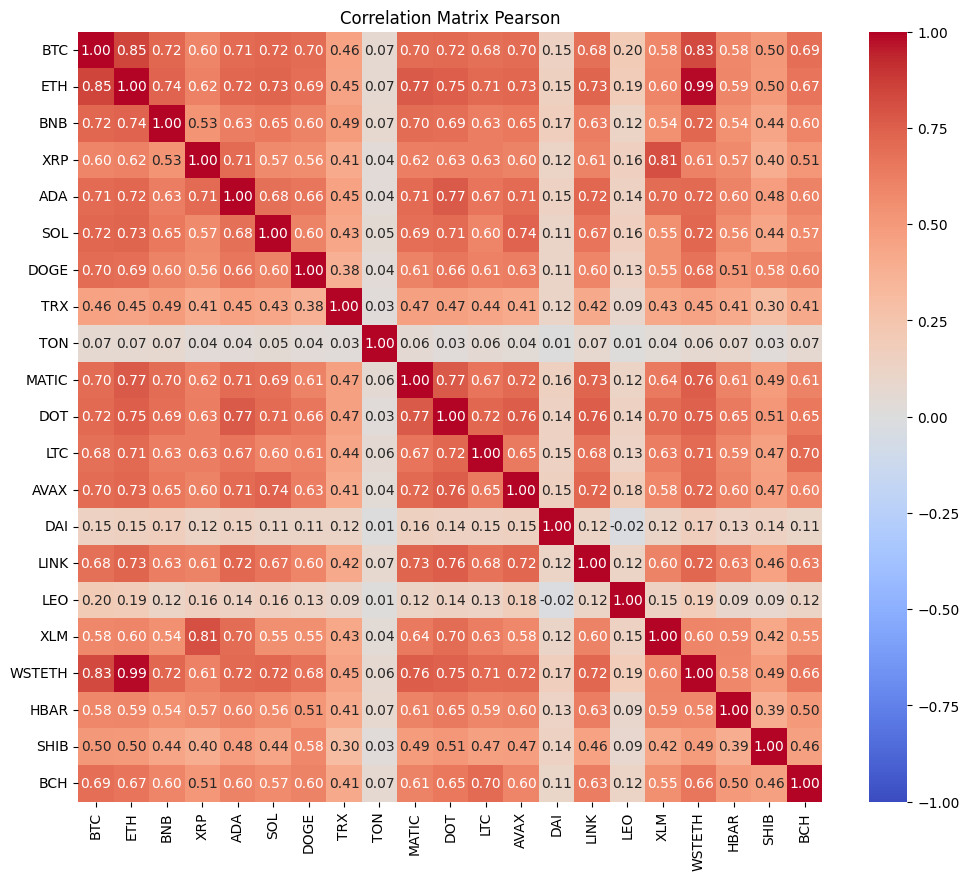

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(log_returns.corr(method='pearson'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix Pearson")
plt.savefig("correlation_matrix_pearson.svg", format='svg', bbox_inches='tight')
plt.show()

In [8]:
corr=log_returns.corr(method='pearson')

In [9]:
# GRAFO DE CORRELAÇÃO
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# **CONECTARLOS SI TIENEN CORRELACION SPEARMAN MAYOR A 0.7**

In [10]:
# Create a graph from the correlation matrix
G = nx.Graph()

In [11]:
threshold = 0.7

In [12]:
# Add edges to the graph based on the correlation values
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            G.add_edge(corr.columns[i], corr.columns[j], weight=corr.iloc[i, j])

In [13]:
# add the nodes in the graph that are not connected
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) < threshold:
            G.add_node(corr.columns[i])
            G.add_node(corr.columns[j])

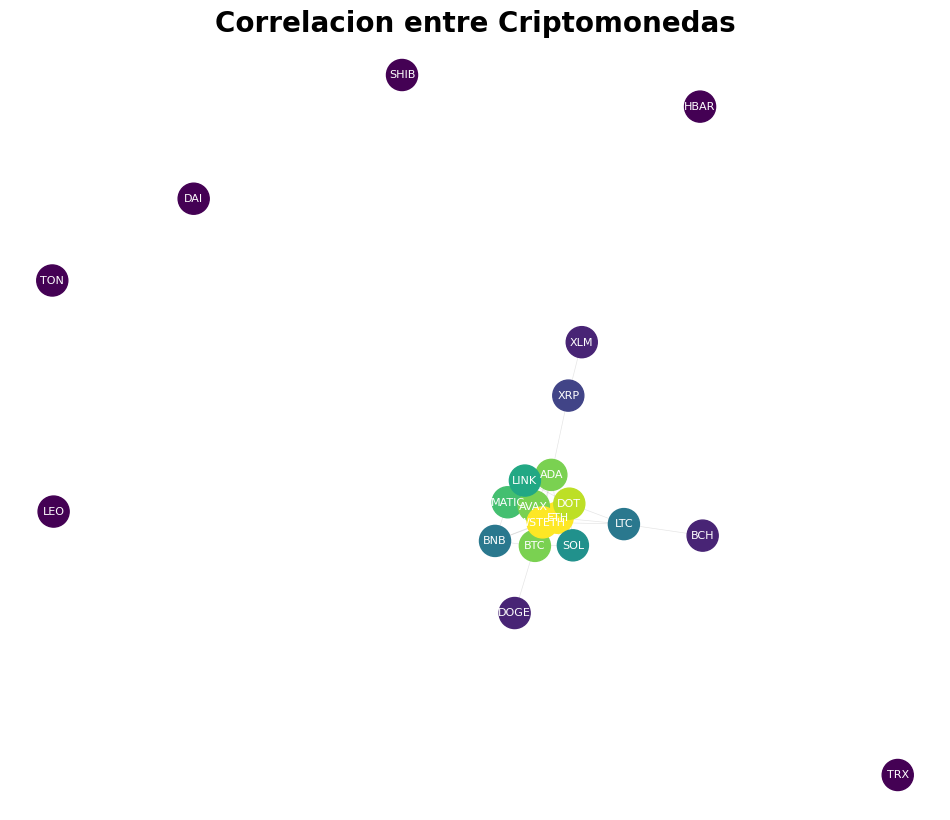

In [14]:
# Set node colors based on degree
node_colors = [G.degree(node) for node in G.nodes()]

# Draw the graph
pos = nx.spring_layout(G)
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500)

nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.1)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
plt.axis('off')
plt.title("Correlacion entre Criptomonedas", fontsize=20, fontweight='bold')

plt.savefig("correlation_graph.svg", format='svg', bbox_inches='tight')
plt.show()

## **CONECTARLOS Y ALEJARLOS DEPENDIENDO DE LOS PESOS**

In [15]:
# Create a graph from the correlation matrix
G = nx.Graph()

In [16]:
dist_corr = 1 - abs(corr)

In [17]:
# Add edges to the graph based on the correlation values
for i in range(len(corr.columns)):
    for j in range(i):
        G.add_edge(dist_corr.columns[i], dist_corr.columns[j], weight=dist_corr.iloc[i, j])

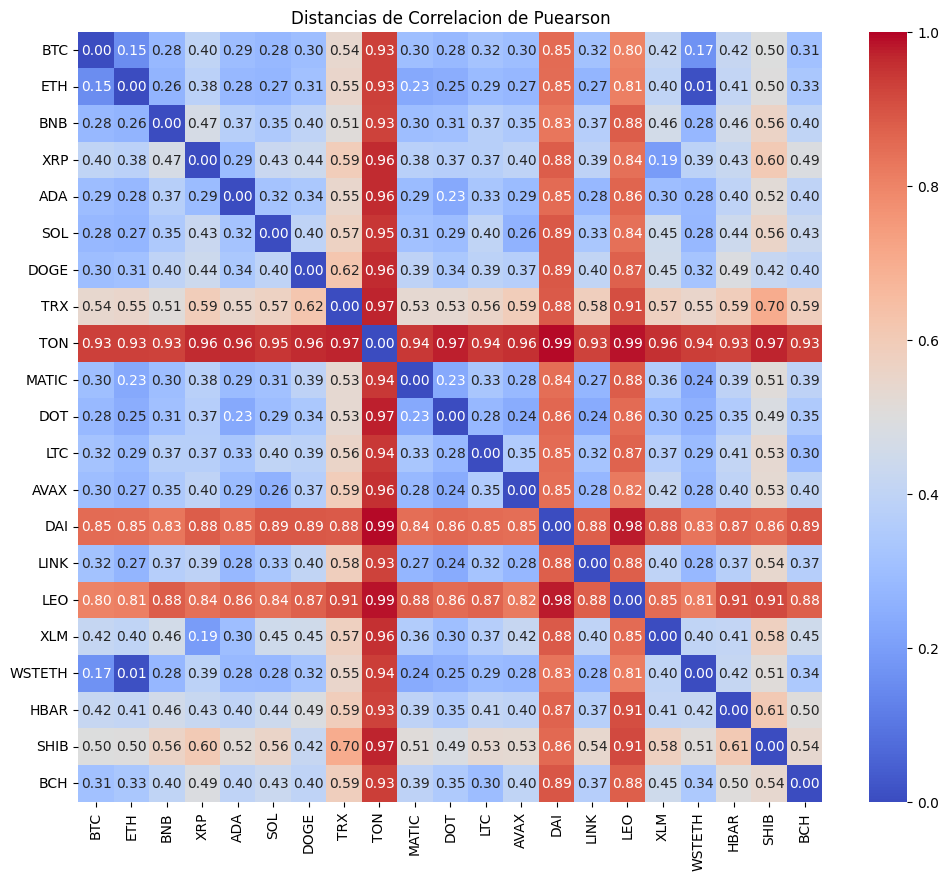

In [18]:
plt.figure(figsize=(12, 10))
sns.heatmap(dist_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Distancias de Correlacion de Puearson")
plt.savefig("d-correlation_matrix_pearson.svg", format='svg', bbox_inches='tight')
plt.show()

In [19]:
classification = {
    'BTC': 'Mayor Cap. Mercado',
    'ETH': 'Mayor Cap. Mercado',
    'USDT': 'Stablecoins',
    'BNB': 'Mayor Cap. Mercado',
    'USDC': 'Stablecoins',
    'XRP': 'Mayor Cap. Mercado',
    'ADA': 'Mayor Cap. Mercado',
    'SOL': 'Mayor Cap. Mercado',
    'DOGE': 'Memecoins',
    'DAI': 'Stablecoins',
    'TRX': 'Tokens Blockchain',
    'TON': 'Tokens Blockchain',
    'MATIC': 'Tokens Blockchain',
    'DOT': 'Tokens Blockchain',
    'AVAX': 'Tokens Blockchain',
    'STETH': 'Tokens Blockchain',
    'WSTETH': 'Activos Envueltos',
    'SUI': 'Tokens Blockchain',
    'WBTC': 'Activos Envueltos',
    'WTRX': 'Activos Envueltos',
    'LTC': 'Pagos & DeFi',
    'LINK': 'Pagos & DeFi',
    'XLM': 'Pagos & DeFi',
    'HBAR': 'Pagos & DeFi',
    'BCH': 'Pagos & DeFi',
    'SHIB': 'Memecoins',
    'LEO': 'Tokens de Exchange'
}

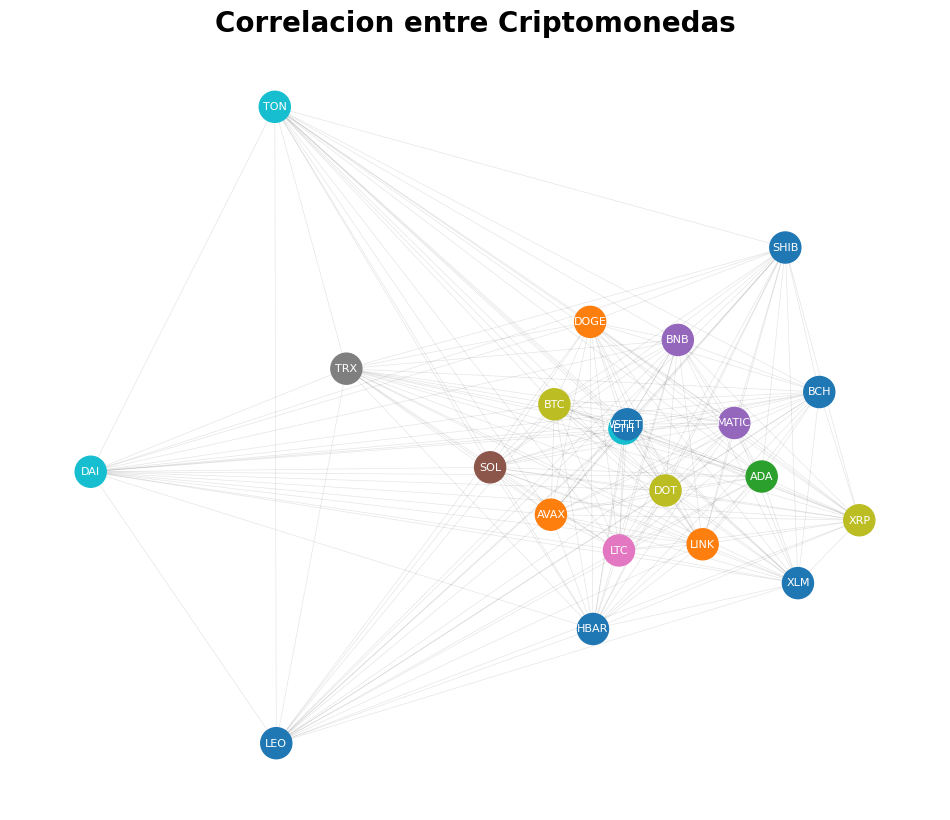

In [20]:
# nx Kamada Kaway layout
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=cm.tab10, node_size=500)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.1)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
plt.axis('off')
plt.title("Correlacion entre Criptomonedas", fontsize=20, fontweight='bold')
plt.savefig("correlation_graph_kamada.svg", format='svg', bbox_inches='tight')
plt.show()

In [21]:
G.edges(data=True)

EdgeDataView([('ETH', 'BTC', {'weight': np.float64(0.15261690199809752)}), ('ETH', 'BNB', {'weight': np.float64(0.2620060975240015)}), ('ETH', 'XRP', {'weight': np.float64(0.3830615080883253)}), ('ETH', 'ADA', {'weight': np.float64(0.2775602388421783)}), ('ETH', 'SOL', {'weight': np.float64(0.27128042811516295)}), ('ETH', 'DOGE', {'weight': np.float64(0.3124480142289602)}), ('ETH', 'TRX', {'weight': np.float64(0.5501911701289077)}), ('ETH', 'TON', {'weight': np.float64(0.9311845450020599)}), ('ETH', 'MATIC', {'weight': np.float64(0.2309025151574211)}), ('ETH', 'DOT', {'weight': np.float64(0.24526582713816103)}), ('ETH', 'LTC', {'weight': np.float64(0.28605834384927376)}), ('ETH', 'AVAX', {'weight': np.float64(0.27357304873549304)}), ('ETH', 'DAI', {'weight': np.float64(0.8515310272653371)}), ('ETH', 'LINK', {'weight': np.float64(0.26614454024515966)}), ('ETH', 'LEO', {'weight': np.float64(0.8123359291555494)}), ('ETH', 'XLM', {'weight': np.float64(0.3997933693104938)}), ('ETH', 'WSTETH

# **CAUSALIDAD**

In [23]:
from statsmodels.tsa.stattools import grangercausalitytests

# Perform the Granger causality test with a maximum lag of 4
# The test checks if BTC (first column) Granger-causes ETH (second column)
grangercausalitytests(data[['BTC', 'ETH']], maxlag=4, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.3270  , p=0.0684  , df_denom=1251, df_num=1
ssr based chi2 test:   chi2=3.3350  , p=0.0678  , df=1
likelihood ratio test: chi2=3.3305  , p=0.0680  , df=1
parameter F test:         F=3.3270  , p=0.0684  , df_denom=1251, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.6487  , p=0.1927  , df_denom=1248, df_num=2
ssr based chi2 test:   chi2=3.3105  , p=0.1910  , df=2
likelihood ratio test: chi2=3.3062  , p=0.1915  , df=2
parameter F test:         F=1.6487  , p=0.1927  , df_denom=1248, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.2324  , p=0.2965  , df_denom=1245, df_num=3
ssr based chi2 test:   chi2=3.7181  , p=0.2936  , df=3
likelihood ratio test: chi2=3.7126  , p=0.2942  , df=3
parameter F test:         F=1.2324  , p=0.2965  , df_denom=1245, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.0906  , p=0.

/home/codespace/.python/current/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(3.326993096392048),
    np.float64(0.06838983274292883),
    np.float64(1251.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(3.33497149710282),
    np.float64(0.0678215819423824),
    np.int64(1)),
   'lrtest': (np.float64(3.330544720778562),
    np.float64(0.06800434848026984),
    np.int64(1)),
   'params_ftest': (np.float64(3.326993096392281),
    np.float64(0.06838983274291649),
    np.float64(1251.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.6486621504485401),
    np.float64(0.19272556888263753),
    np.float64(1248.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(3.310534734794905),
    np.float64(0.19104097074938703),
    np.int64(2)),
   'lrtest': (np.float64(3.306169062732806),
    np.float64(0.19145843732852968),
    np.int64(2)),
   'params_ftest': (np.float64(1.648662150449124),
    np.float64(0.1927255688825377),
    np.float64(1248.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
    